In [1]:
#Sentiment Analysis

import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
BRAND_COLORS     = {"Wired": "#1A1A1A", "The Verge": "#FA4B2A"}
SENTIMENT_COLORS = {"positive": "#2CA02C", "neutral": "#9E9E9E", "negative": "#D62728"}

wired_posts = pd.read_csv(PROC_DIR / "wired_posts_clean.csv")
verge_posts = pd.read_csv(PROC_DIR / "verge_posts_clean.csv")

for df, brand in [(wired_posts, "Wired"), (verge_posts, "The Verge")]:
    df["brand"] = brand
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True).dt.tz_convert(None)
    
    for col in ["like_count", "repost_count", "reply_count"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print(f"Loaded {len(wired_posts)} Wired posts and {len(verge_posts)} Verge posts.")

Loaded 1578 Wired posts and 1153 Verge posts.


In [2]:
from typing import cast

analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return float(analyzer.polarity_scores(text)["compound"])

def textblob_subjectivity(text: str) -> float:
    if not isinstance(text, str) or not text.strip():
        return 0.0

    polarity, subjectivity = cast(tuple[float, float], TextBlob(text).sentiment)
    return float(subjectivity)

def categorise(compound: float) -> str:
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

wired_posts["brand"] = "Wired"
verge_posts["brand"] = "The Verge"

for df in (wired_posts, verge_posts):
    df["vader_compound"] = df["text_for_sentiment"].apply(vader_compound)
    df["subjectivity"] = df["text_for_sentiment"].apply(textblob_subjectivity)
    df["sentiment"] = df["vader_compound"].apply(categorise)

all_posts = pd.concat([wired_posts, verge_posts], ignore_index=True)

sentiment_summary = all_posts.groupby("brand").agg(
    n_posts           = ("uri",            "count"),
    mean_compound     = ("vader_compound", "mean"),
    median_compound   = ("vader_compound", "median"),
    std_compound      = ("vader_compound", "std"),
    mean_subjectivity = ("subjectivity",   "mean"),
    pct_positive      = ("sentiment", lambda s: (s == "positive").mean() * 100),
    pct_neutral       = ("sentiment", lambda s: (s == "neutral").mean()  * 100),
    pct_negative      = ("sentiment", lambda s: (s == "negative").mean() * 100),
).round(3)

print("Sentiment summary by brand:")
print(sentiment_summary.T)

sentiment_summary.T.to_csv(TAB_DIR / "05_sentiment_summary.csv")

Sentiment summary by brand:
brand              The Verge     Wired
n_posts             1153.000  1578.000
mean_compound          0.137     0.079
median_compound        0.009     0.000
std_compound           0.473     0.472
mean_subjectivity      0.419     0.384
pct_positive          49.436    43.599
pct_neutral           23.330    26.679
pct_negative          27.233    29.721


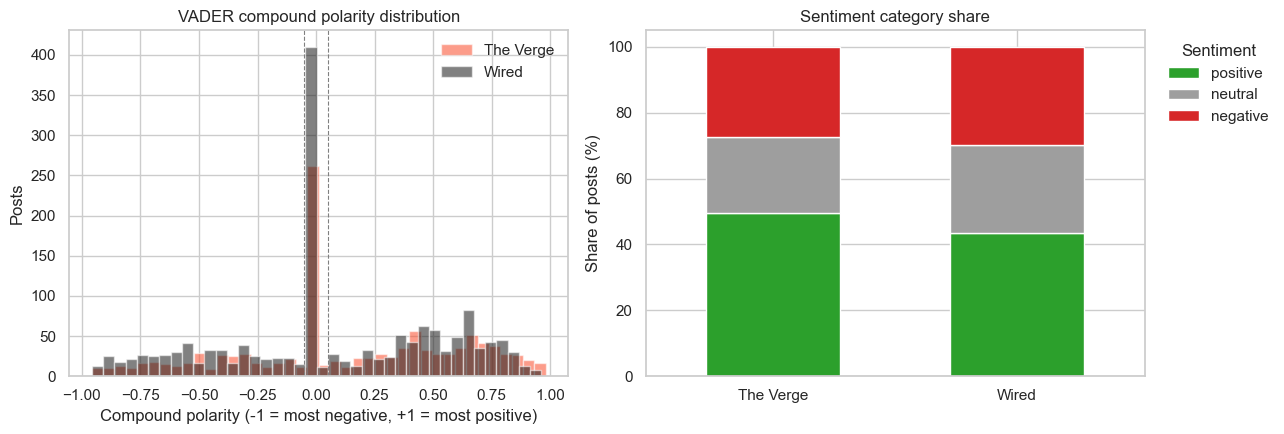

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Polarity histogram
ax = axes[0]

for brand, g in all_posts.groupby("brand"):
    brand_name = str(brand)

    ax.hist(
        pd.to_numeric(g["vader_compound"], errors="coerce").fillna(0).to_numpy(dtype=float),
        bins=40,
        alpha=0.55,
        label=brand_name,
        color=BRAND_COLORS.get(brand_name, "lightgrey")
    )

ax.axvline(0.05, color="grey", ls="--", lw=0.8)
ax.axvline(-0.05, color="grey", ls="--", lw=0.8)
ax.set_title("VADER compound polarity distribution")
ax.set_xlabel("Compound polarity (-1 = most negative, +1 = most positive)")
ax.set_ylabel("Posts")
ax.legend(frameon=False)


# (b) Stacked share of positive / neutral / negative
ax = axes[1]

cat_pct = (
    all_posts.groupby(["brand", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

for col in ["positive", "neutral", "negative"]:
    if col not in cat_pct.columns:
        cat_pct[col] = 0

cat_pct = (
    cat_pct[["positive", "neutral", "negative"]]
    .div(all_posts.groupby("brand").size(), axis=0)
    * 100
)

cat_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[SENTIMENT_COLORS.get(str(c), "lightgrey") for c in cat_pct.columns],
    width=0.55
)

ax.set_title("Sentiment category share")
ax.set_ylabel("Share of posts (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Sentiment",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

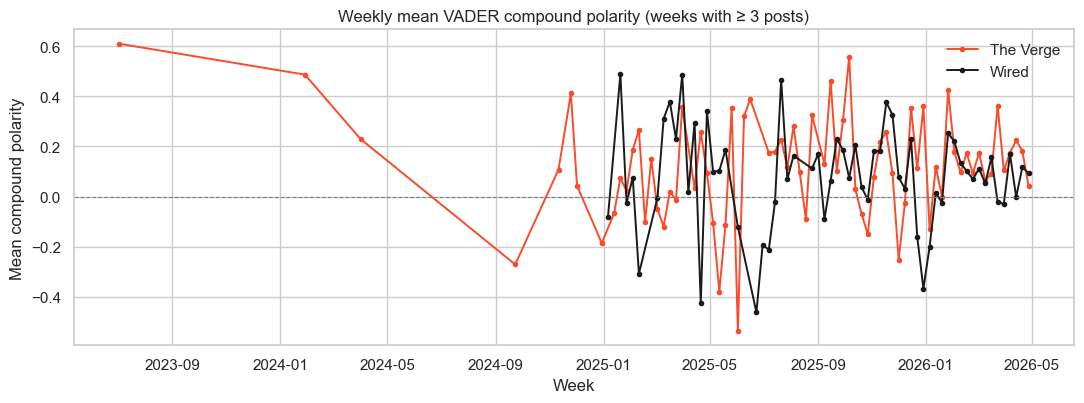

In [4]:
# Weekly mean polarity, gated to weeks with at least 3 posts to avoid noise spikes.
weekly_sent = (
    all_posts.dropna(subset=["created_at"])
    .assign(
        week=lambda d: pd.to_datetime(d["created_at"], errors="coerce")
        .dt.to_period("W")
        .dt.to_timestamp()
    )
    .groupby(["week", "brand"])
    .agg(
        mean_polarity=("vader_compound", "mean"),
        n=("uri", "count")
    )
    .reset_index()
)

weekly_sent = weekly_sent[weekly_sent["n"] >= 3]

fig, ax = plt.subplots(figsize=(11, 4.2))

for brand, g in weekly_sent.groupby("brand"):
    brand_name = str(brand)

    ax.plot(
        g["week"],
        pd.to_numeric(g["mean_polarity"], errors="coerce").fillna(0).to_numpy(dtype=float),
        label=brand_name,
        color=BRAND_COLORS.get(brand_name, "lightgrey"),
        linewidth=1.4,
        marker="o",
        markersize=3
    )

ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_title("Weekly mean VADER compound polarity (weeks with ≥ 3 posts)")
ax.set_xlabel("Week")
ax.set_ylabel("Mean compound polarity")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

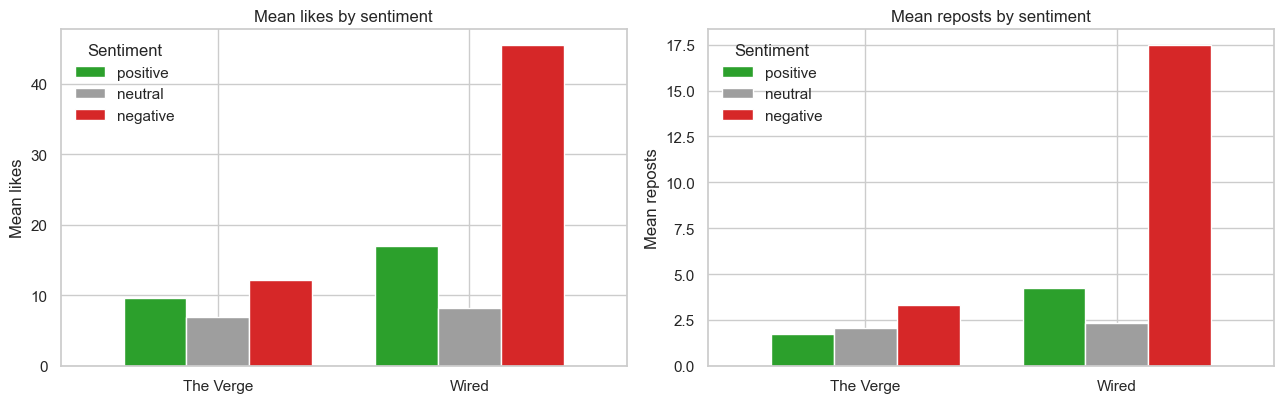

Sentiment by post type:
                        n  mean_compound  mean_subjectivity  pct_positive  \
brand     post_type                                                         
The Verge Original    731          0.138              0.414        49.795   
          Reply       422          0.135              0.430        48.815   
Wired     Original   1262          0.074              0.376        42.868   
          Reply       316          0.097              0.415        46.519   

                     pct_negative  
brand     post_type                
The Verge Original         26.129  
          Reply            29.147  
Wired     Original         30.032  
          Reply            28.481  


In [5]:
# (a) Does sentiment predict engagement? On social platforms, negative content often outperforms, worth checking.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

eng_by_sent = (
    all_posts.groupby(["brand", "sentiment"]).agg(
        n            = ("uri",          "count"),
        mean_likes   = ("like_count",   "mean"),
        mean_reposts = ("repost_count", "mean"),
    ).reset_index()
)

for ax, metric, title in zip(
    axes,
    ["mean_likes", "mean_reposts"],
    ["Mean likes by sentiment", "Mean reposts by sentiment"],
):
    pivot = (
        eng_by_sent
        .pivot(index="brand", columns="sentiment", values=metric)
        [["positive", "neutral", "negative"]]
    )
    pivot.plot(kind="bar", ax=ax,
               color=[SENTIMENT_COLORS[c] for c in pivot.columns],
               width=0.75)
    ax.set_title(title)
    ax.set_ylabel(title.split(" by ")[0])
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Sentiment", frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "09_sentiment_vs_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

# (b) Are replies more emotionally charged than originals?
post_type_sent = (
    all_posts
    .assign(post_type=lambda d: np.where(d["is_reply"], "Reply", "Original"))
    .groupby(["brand", "post_type"]).agg(
        n                 = ("uri",            "count"),
        mean_compound     = ("vader_compound", "mean"),
        mean_subjectivity = ("subjectivity",   "mean"),
        pct_positive      = ("sentiment", lambda s: (s == "positive").mean() * 100),
        pct_negative      = ("sentiment", lambda s: (s == "negative").mean() * 100),
    ).round(3)
)
print("Sentiment by post type:")
print(post_type_sent)
post_type_sent.to_csv(TAB_DIR / "06_sentiment_by_post_type.csv")

In [6]:
# A handful of examples per pole useful for the Analysis section to ground the numbers in real text truncated to 200 chars to keep output readable.
def show_examples(df: pd.DataFrame, brand: str, n: int = 4) -> None:
    print(f"\n=== {brand} - most positive (high compound) ===")
    for _, row in df.nlargest(n, "vader_compound").iterrows():
        snippet = str(row["text_raw"])[:200].replace("\n", " ")
        print(f"  [pol={row['vader_compound']:+.2f}, likes={int(row['like_count'])}] {snippet}…")

    print(f"\n=== {brand} - most negative (low compound) ===")
    for _, row in df.nsmallest(n, "vader_compound").iterrows():
        snippet = str(row["text_raw"])[:200].replace("\n", " ")
        print(f"  [pol={row['vader_compound']:+.2f}, likes={int(row['like_count'])}] {snippet}…")

show_examples(wired_posts, "Wired")
show_examples(verge_posts, "The Verge")


=== Wired - most positive (high compound) ===
  [pol=+0.96, likes=4] Congrats to our friends at @wired.com for their excellent DOGE coverage, which just won them the Sidney Hillman Prize. Well deserved!…
  [pol=+0.95, likes=242] Thrilled, honored, and so proud of @wired.com for winning the 2026 Hillman Prize for Magazine Journalism:  "WIRED’s stories were not only groundbreaking; they were singular."…
  [pol=+0.95, likes=1] EVERYONE CALM DOWN THE ADL SAID IT'S COOL  You know cuz he is pro israel...  WIRED REPORTS: "Neo-Nazis Love the Nazi-Like Salutes Elon Musk Made at Trump's Inauguration The far right is celebrating wh…
  [pol=+0.94, likes=0] @cbssundaymorning.bsky.social so very nice to see Nick Thompson again in this wonderful and emotional story. For many of us for decades he taught us technology via Wired and TV PAs, and I was so glad …

=== Wired - most negative (low compound) ===
  [pol=-0.96, likes=176] Wired reports chaos in Trump’s White House, with officials deeply worried

In [7]:
# Author-level sentiment feeds directly into Phase 7's micro-influencer scoring.
def author_sentiment(posts: pd.DataFrame) -> pd.DataFrame:
    return (
        posts.groupby("author_did").agg(
            posts             = ("uri",            "count"),
            mean_compound     = ("vader_compound", "mean"),
            mean_subjectivity = ("subjectivity",   "mean"),
            pct_positive      = ("sentiment", lambda s: (s == "positive").mean() * 100),
            pct_negative      = ("sentiment", lambda s: (s == "negative").mean() * 100),
            total_likes       = ("like_count",     "sum"),
            total_reposts     = ("repost_count",   "sum"),
        ).reset_index()
    )

wired_author_sent = author_sentiment(wired_posts)
verge_author_sent = author_sentiment(verge_posts)

wired_author_sent.to_csv(TAB_DIR / "07_wired_author_sentiment.csv", index=False)
verge_author_sent.to_csv(TAB_DIR / "07_verge_author_sentiment.csv", index=False)

# Sentiment-scored full posts required input for topic modelling and influencer phases
wired_posts.to_csv(PROC_DIR / "wired_posts_sentiment.csv", index=False)
verge_posts.to_csv(PROC_DIR / "verge_posts_sentiment.csv", index=False)

post_type_sent_json = {}

for idx, metrics in post_type_sent.to_dict("index").items():
    if isinstance(idx, tuple) and len(idx) == 2:
        brand, post_type = idx
        key = f"{brand}|{post_type}"
    else:
        key = str(idx)

    post_type_sent_json[key] = metrics


sentiment_summary_dict = {
    "summary_by_brand": sentiment_summary.to_dict(),
    "post_type_summary": post_type_sent_json,
    "method_notes": [
        "VADER (vaderSentiment) used for compound polarity - chosen over TextBlob "
        "polarity because VADER's lexicon is tuned for social-media features "
        "(emojis, slang, intensifiers, negation) which dominate Bluesky posts.",
        "TextBlob subjectivity retained as a second axis (factual vs opinion-laden), "
        "orthogonal to polarity.",
        "Standard VADER thresholds: compound >= +0.05 -> positive, "
        "<= -0.05 -> negative, otherwise neutral.",
        "Sentiment scored on text_for_sentiment: URLs, mentions and hashtags "
        "stripped, casing and punctuation preserved.",
    ],
}

with open(PROC_DIR / "sentiment_summary.json", "w") as f:
    json.dump(sentiment_summary_dict, f, indent=2, default=str)

print("\nSaved:")
print(" • data/processed/wired_posts_sentiment.csv")
print(" • data/processed/verge_posts_sentiment.csv")
print(" • data/processed/sentiment_summary.json")
print(" • outputs/tables/05-07_*.csv")
print(" • outputs/figures/07-09_*.png")


Saved:
 • data/processed/wired_posts_sentiment.csv
 • data/processed/verge_posts_sentiment.csv
 • data/processed/sentiment_summary.json
 • outputs/tables/05-07_*.csv
 • outputs/figures/07-09_*.png
